# Steel NPV summary

Run the steel Monte Carlo NPV distribution, deterministic NPV, and Monte Carlo ranking summaries. BF-BOF + post-combustion CCS and NG-DRI-EAF + CCS are BAU-relative retrofits; the settings cell selects sampled or deterministic BAU inputs for their Monte Carlo runs. This notebook displays figures inline only; it does not save figures or CSV files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_deterministic import calculate_deterministic_steel_results
from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)
from steel.steel_npv_summary_figures import (
    STEEL_FINANCIAL_METRIC_OPTIONS,
    STEEL_TECHNOLOGY_LABELS,
    calculate_steel_npv_rankings_from_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_average_rank_bars, plot_financial_metric_technology_bars


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = tuple(STEEL_TECHNOLOGY_LABELS)
FINANCIAL_METRIC = "LNM"  # "NPV", "LNM", or "LCOX"

if FINANCIAL_METRIC not in STEEL_FINANCIAL_METRIC_OPTIONS:
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")

METRIC_CONFIG = STEEL_FINANCIAL_METRIC_OPTIONS[FINANCIAL_METRIC]
METRIC_COLUMN = str(METRIC_CONFIG["metric_column"])
METRIC_SCALE_FACTOR = float(METRIC_CONFIG["scale"])
METRIC_SUMMARY_COLUMN = str(METRIC_CONFIG["summary_column"])
METRIC_AXIS_LABEL = str(METRIC_CONFIG["axis_label"])
METRIC_RANKING_LABEL = str(METRIC_CONFIG["ranking_label"])
METRIC_HIGHER_IS_BETTER = bool(METRIC_CONFIG["higher_is_better"])
METRIC_COLOR_BY_SIGN = bool(METRIC_CONFIG["color_by_sign"])
METRIC_ZERO_BASELINE = bool(METRIC_CONFIG["zero_baseline"])

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo NPV distribution

,label,technology_type,levelized_net_margin_eur_per_tcs,median,p05,p95,non_negative_count,negative_count,non_negative_share
1,Scrap-EAF,absolute,-244.086,-241.889,-315.484,-179.403,0,100000,0.000
0,BF-BOF BAU,absolute,-262.179,-264.059,-288.341,-230.501,0,100000,0.000
6,BF-BOF + post-combustion CCS,retrofit,-292.658,-289.047,-380.837,-216.136,0,100000,0.000
2,NG-DRI-EAF BAU,absolute,-315.690,-315.518,-404.825,-227.117,0,100000,0.000
7,NG-DRI-EAF + CCS,retrofit,-384.392,-386.124,-486.093,-277.784,0,100000,0.000
3,H2-DRI-EAF,absolute,-548.050,-545.554,-651.939,-452.864,0,100000,0.000
5,AEL-EAF,absolute,-627.829,-637.627,-835.975,-384.671,0,100000,0.000
4,MOE,absolute,-697.134,-703.295,-952.453,-422.741,0,100000,0.000


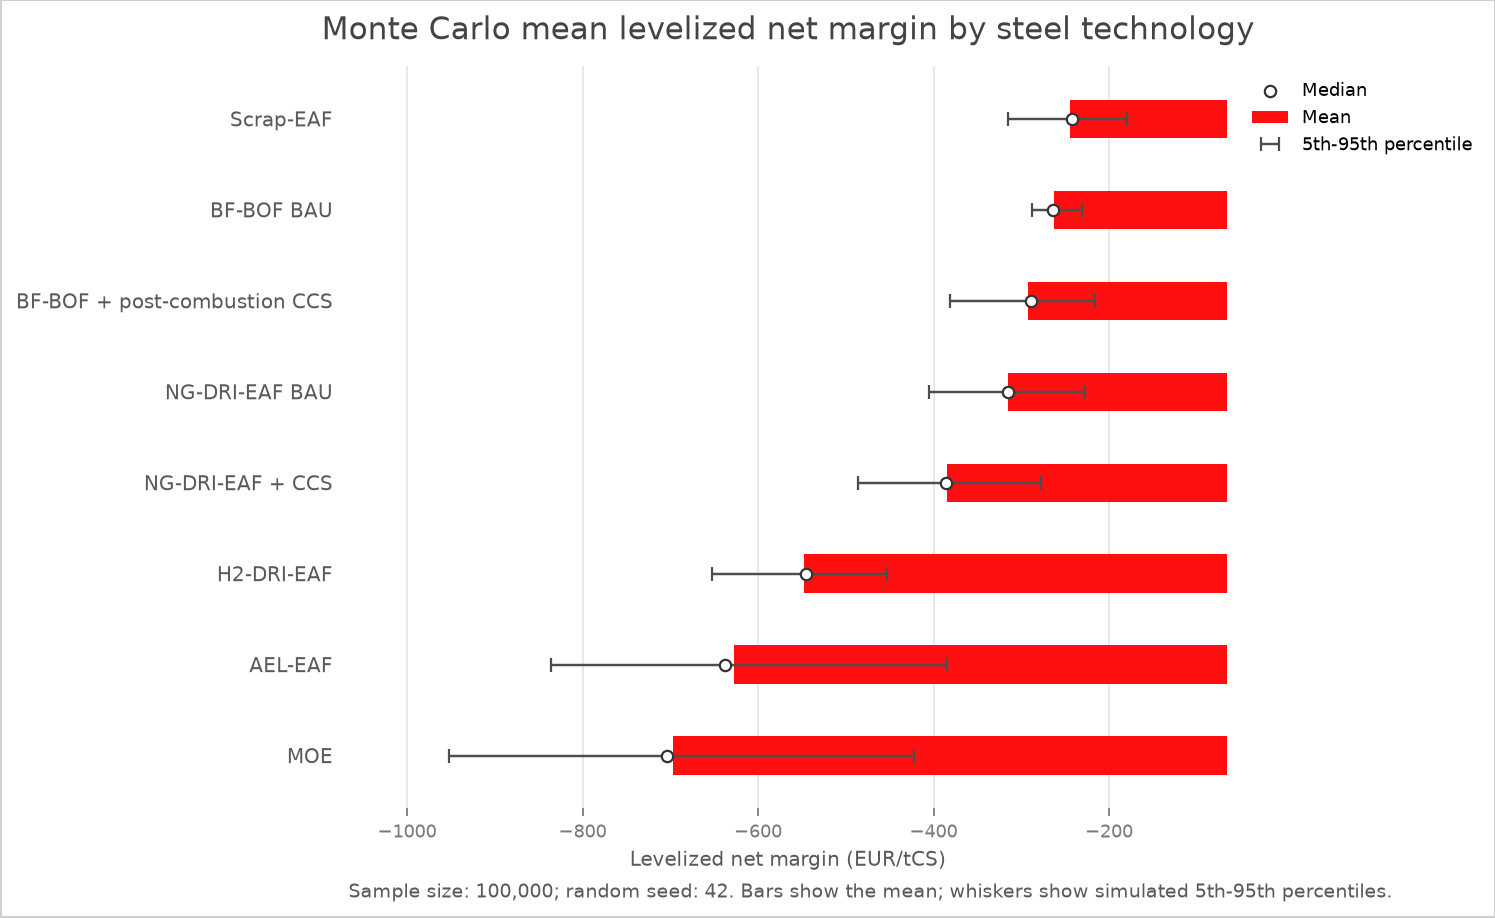

In [3]:
monte_carlo_results = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[METRIC_COLUMN], dtype=float) / METRIC_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": STEEL_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
            **summarize_metric_signs(values),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(
    METRIC_SUMMARY_COLUMN, ascending=not METRIC_HIGHER_IS_BETTER
)
mc_summary_by_label = mc_summary.set_index("label")

display(mc_summary)
plot_financial_metric_technology_bars(
    values=mc_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {METRIC_RANKING_LABEL} by steel technology",
    median_values=mc_summary_by_label["median"].to_dict(),
    lower_values=mc_summary_by_label["p05"].to_dict(),
    upper_values=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=METRIC_AXIS_LABEL,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
    color_by_sign=METRIC_COLOR_BY_SIGN,
    zero_baseline=METRIC_ZERO_BASELINE,
)
plt.show()


## Deterministic NPV

,label,technology_type,levelized_net_margin_eur_per_tcs
1,Scrap-EAF,absolute,-202.228
0,BF-BOF BAU,absolute,-282.902
6,BF-BOF + post-combustion CCS,retrofit,-303.210
2,NG-DRI-EAF BAU,absolute,-309.754
7,NG-DRI-EAF + CCS,retrofit,-384.929
3,H2-DRI-EAF,absolute,-491.057
5,AEL-EAF,absolute,-616.744
4,MOE,absolute,-675.022


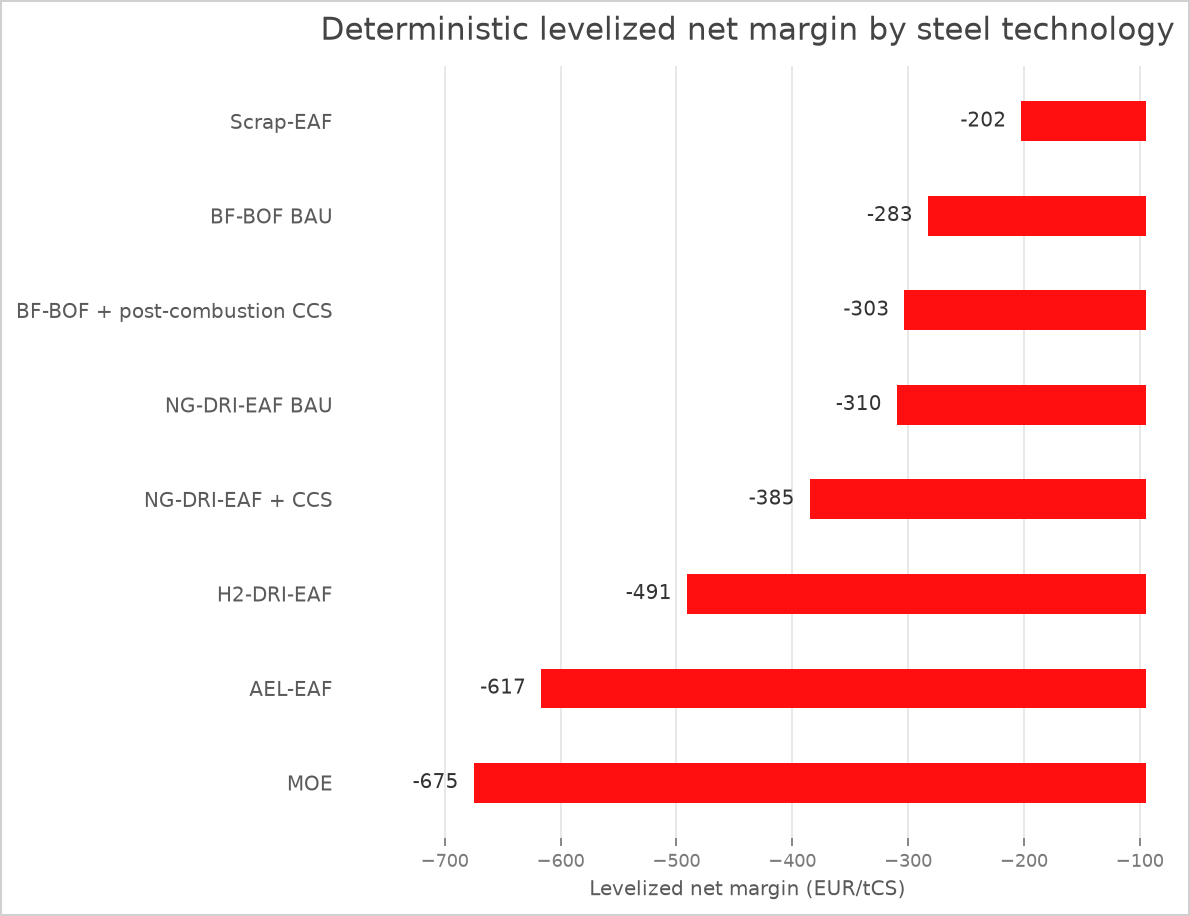

In [4]:
deterministic_results = calculate_deterministic_steel_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": STEEL_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: float(np.asarray(results[METRIC_COLUMN]).item()) / METRIC_SCALE_FACTOR,
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(
    METRIC_SUMMARY_COLUMN, ascending=not METRIC_HIGHER_IS_BETTER
)

display(det_summary)
plot_financial_metric_technology_bars(
    values=det_summary.set_index("label")[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {METRIC_RANKING_LABEL} by steel technology",
    x_axis_label=METRIC_AXIS_LABEL,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
    color_by_sign=METRIC_COLOR_BY_SIGN,
    zero_baseline=METRIC_ZERO_BASELINE,
)
plt.show()


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,Scrap-EAF,1.625,0.597,0.964,100000
1,BF-BOF BAU,2.165,0.225,0.931,100000
2,BF-BOF + post-combustion CCS,2.960,0.137,0.660,100000
3,NG-DRI-EAF BAU,3.375,0.040,0.424,100000
4,NG-DRI-EAF + CCS,4.901,0.000,0.020,100000
5,H2-DRI-EAF,6.407,0.000,0.000,100000
6,AEL-EAF,6.945,0.000,0.001,100000
7,MOE,7.622,0.000,0.001,100000


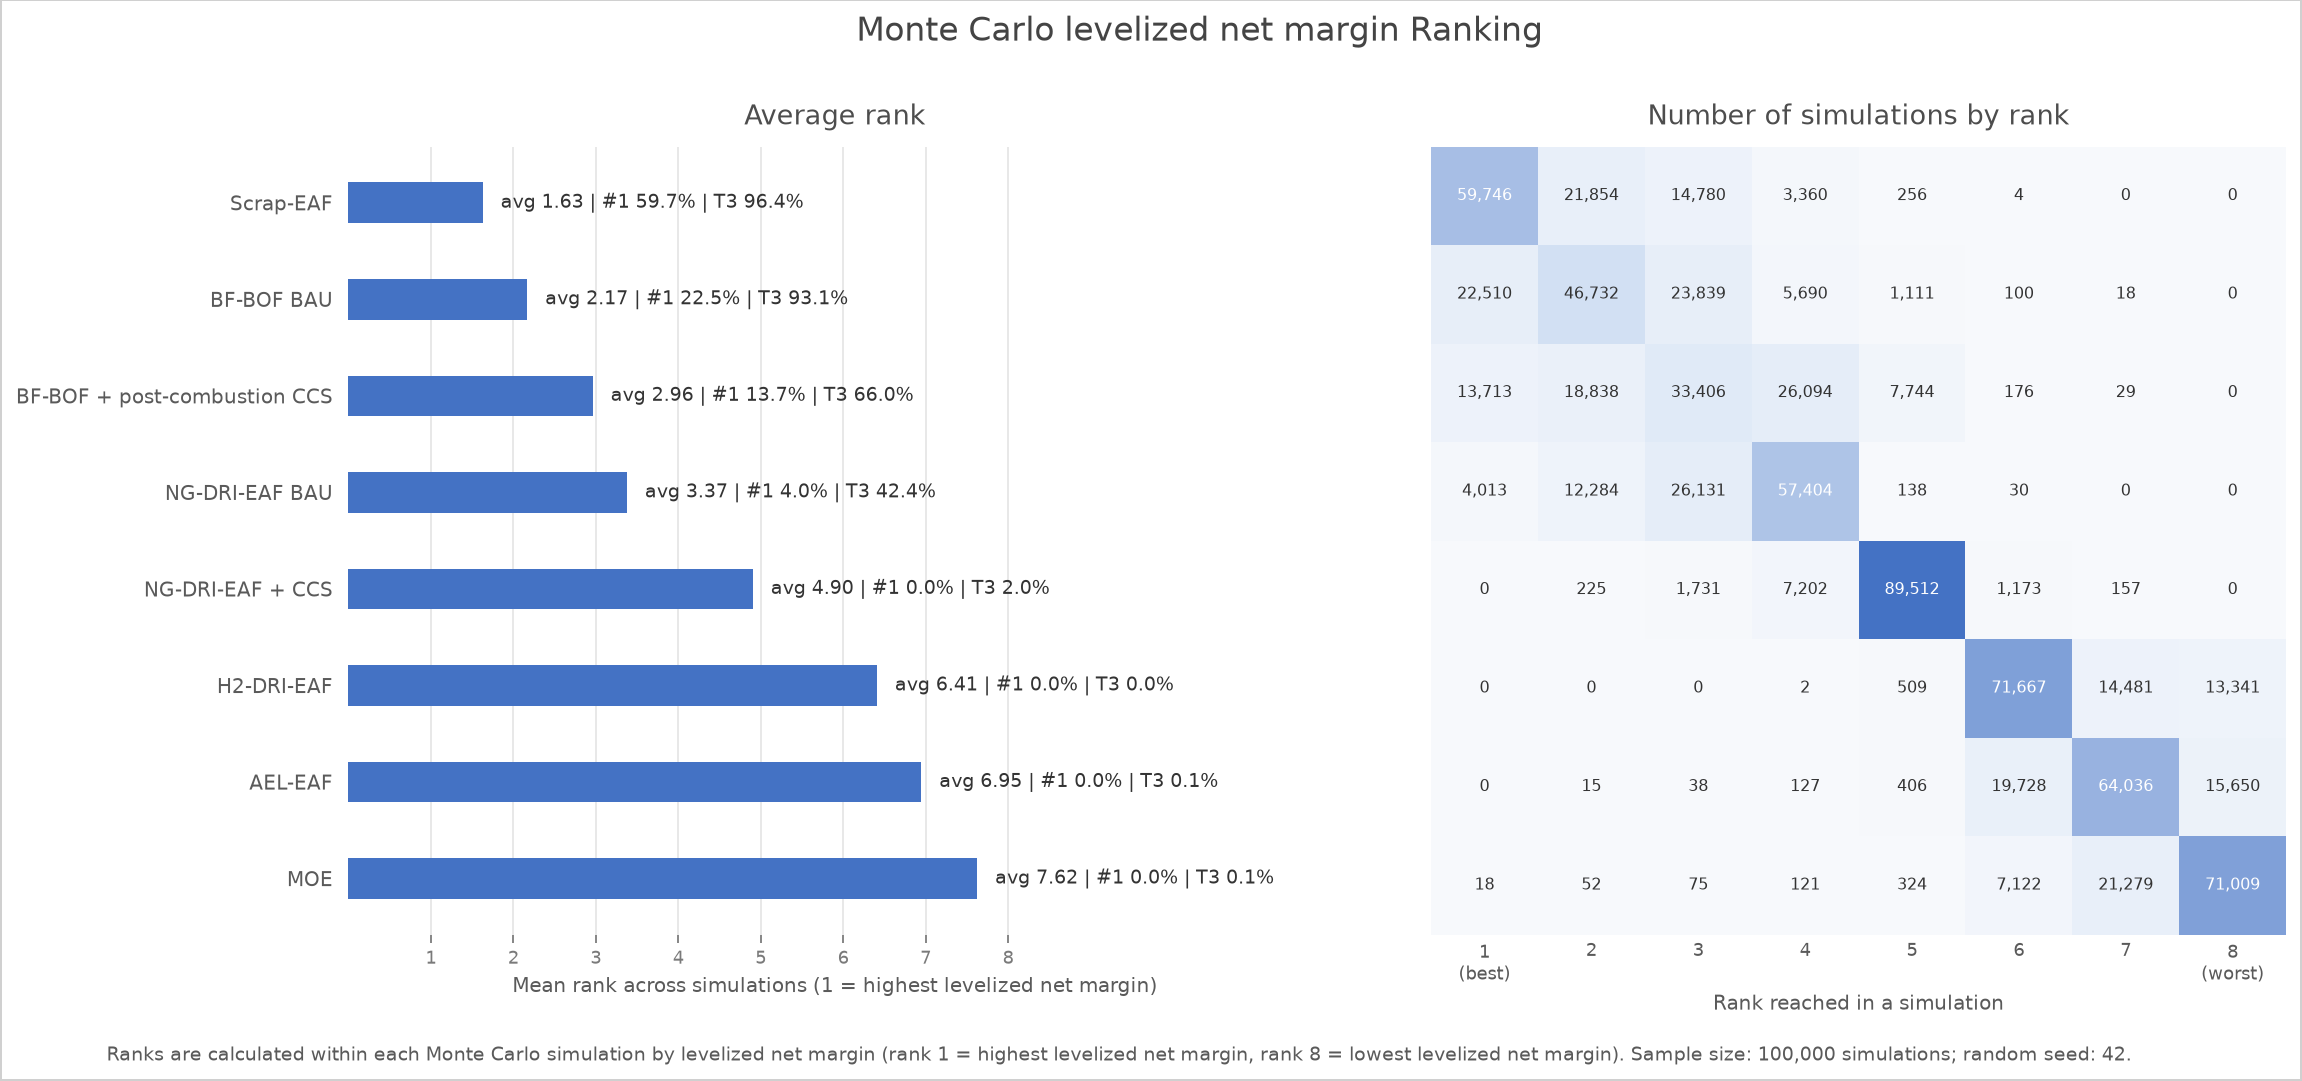

In [5]:
ranking_raw, ranking_summary = calculate_steel_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Steel",
    financial_metric=FINANCIAL_METRIC,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(STEEL_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {METRIC_RANKING_LABEL} Ranking",
    metric_label=METRIC_RANKING_LABEL,
    random_seed=RANDOM_SEED,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
)
plt.show()
